# Tissue DMR detection
Blood v. Brain plots for figure 1.

##### Modules

In [2]:
import pandas as pd
import numpy as np
import time
import psutil
import os
import re
from pybedtools import BedTool

import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Fonts & Colors

In [3]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# font size
b = 1
title_size = 18 + b
label_size = 16 + b
tick_size = 12 + b

color_dict = dict(zip(['unsmoothed', 'smoothed', 'modkit'], plt.cm.Dark2.colors[:3]))

##### Inputs

In [4]:
seg_cols = [
    'chrom',
    'start',
    'end',
    'state_name',
    'score',
    'n_sites',
    'a_counts',
    'b_counts',
    'a_mod_percentages',
    'b_mod_percentages',
    'a_frac_modified',
    'b_frac_modified',
    'effect_size',
    'cohen_h', 
    'cohen_h_low',
    'cohen_h_high'
]

In [5]:
REF_DIR = '/scratch/eger/projects/MethSmoothEval/tissues/ref_data'

DIR0 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/pileup'
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/dmr'
DIR2 = '/scratch/eger/projects/MethSmoothEval/tissues/DSS'
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis'

## hg002_blood_v_Bulk_FC_Control_02
5kHz samples

In [16]:
sample1 = 'hg002_blood'
sample2 = 'Bulk_FC_Control_02'
pair = sample1+'_v_'+sample2
title = 'Blood1_5kHz v. Brain1_5kHz'

fname1 = os.path.join(DIR2, pair+'_DMLtest_DMRs.tsv')
fname2 = os.path.join(DIR2, pair+'_DMLtestwSmoothing_DMRs.tsv')

In [17]:
# read files
dss_unsmoothed_dmr_df = pd.read_csv(fname1, sep='\t').rename(columns={'chr': 'chrom'})
dss_smoothed_dmr_df = pd.read_csv(fname2, sep='\t').rename(columns={'chr': 'chrom'})

# add columns
dss_unsmoothed_dmr_df['name']=dss_unsmoothed_dmr_df['chrom'].astype(str)+":"+dss_unsmoothed_dmr_df['start'].astype(int).astype(str)+"-"+dss_unsmoothed_dmr_df['end'].astype(int).astype(str)
dss_smoothed_dmr_df['name']=dss_smoothed_dmr_df['chrom'].astype(str)+":"+dss_smoothed_dmr_df['start'].astype(int).astype(str)+"-"+dss_smoothed_dmr_df['end'].astype(int).astype(str)

dss_unsmoothed_dmr_df['type']='unsmoothed'
dss_smoothed_dmr_df['type']='smoothed'

dss_dmr_df = pd.concat([dss_unsmoothed_dmr_df, dss_smoothed_dmr_df], ignore_index=True)

### DMR length
Unsmoothed DMRs are shorter and there are less of them.

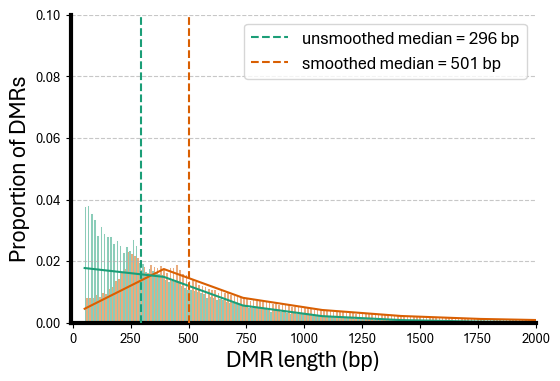

In [18]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# plot per sample entropy distribution histogram with dodge set to true (side by side bars per data type)
ax = sb.histplot(data=dss_dmr_df,
                 x="length",
                 hue="type",
                 palette=color_dict,
                 multiple="dodge",
                 stat="proportion",
                 common_norm=False,
                 kde=True)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
    ax.axvline(median, color=color_dict[region_type], linestyle='--', 
           linewidth=1.5, zorder=4, 
           label=f'{region_type} median = {median} bp')

# set limits
ax.set_xlim(-10, 2000)
ax.set_ylim(0, 0.1)

# label x-axis
ax.set_xlabel("DMR length (bp)", fontsize=label_size)
# label y-axis
ax.set_ylabel("Proportion of DMRs", fontsize=label_size)

ax.legend(fontsize=tick_size)


plt.show()

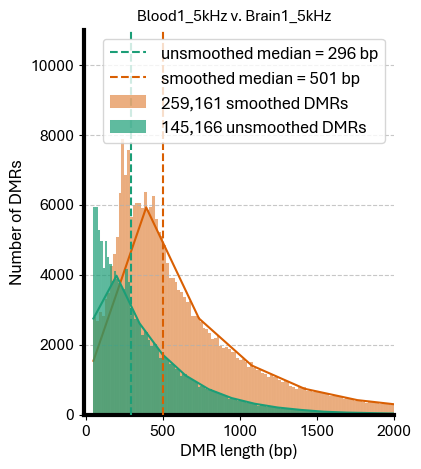

In [84]:
# initialize figure
fig, ax = plt.subplots(figsize=(4, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="length",
    color=color_dict["smoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="length",
    color=color_dict["unsmoothed"],
    stat="count",
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# median lines
for region_type in dss_dmr_df['type'].unique():
    median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
    ax.axvline(
        median,
        color=color_dict[region_type],
        linestyle='--',
        linewidth=1.5,
        zorder=4,
        label=f'{region_type} median = {median} bp'
    )

# limits and labels
ax.set_xlim(-10, 2000)
ax.set_ylim(0, 11000)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlabel("DMR length (bp)", fontsize=tick_size)
ax.set_ylabel("Number of DMRs", fontsize=tick_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

#ax.set_title('Blood v. Brain', fontsize=label_size, pad=15)
plt.suptitle(title, y=0.92)

plt.show()

### DMR effect size
Unsmoothed DMRs have larger effect sizes.

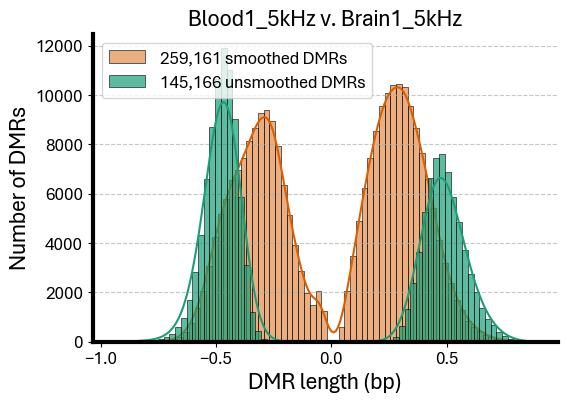

In [20]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# --- plot smoothed FIRST (goes underneath) ---
n = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "smoothed"],
    x="diff.Methy",
    color=color_dict["smoothed"],
    stat="count",
    binwidth=0.025,
    kde=True,
    element="bars",
    alpha=0.5,
    ax=ax,
    label=f"{n:,} smoothed DMRs",
    zorder=1
)

# --- plot unsmoothed SECOND (goes on top) ---
n = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
sb.histplot(
    data=dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"],
    x="diff.Methy",
    color=color_dict["unsmoothed"],
    stat="count",
    binwidth=0.025,
    kde=True,
    element="bars",
    alpha=0.7,
    ax=ax,
    label=f"{n:,} unsmoothed DMRs",
    zorder=2
)

# # median lines
# for region_type in dss_dmr_df['type'].unique():
#     median = dss_dmr_df[dss_dmr_df['type'] == region_type]['length'].median().astype(int)
#     ax.axvline(
#         median,
#         color=color_dict[region_type],
#         linestyle='--',
#         linewidth=1.5,
#         zorder=4,
#         label=f'{region_type} median = {median} bp'
#     )

# limits and labels
ax.tick_params(axis='both', labelsize=tick_size)
ax.set_xlabel("DMR length (bp)", fontsize=label_size)
ax.set_ylabel("Number of DMRs", fontsize=label_size)

# legend (now includes bars + medians)
ax.legend(fontsize=tick_size)

ax.set_title(title, fontsize=label_size)

plt.show()

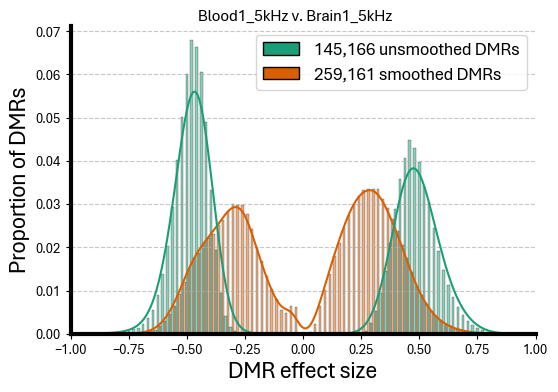

In [22]:
# initialize figure
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

# plot per sample entropy distribution histogram with dodge set to true (side by side bars per data type)
ax = sb.histplot(data=dss_dmr_df,
                 x="diff.Methy",
                 hue="type",
                 palette=color_dict,
                 multiple="dodge",
                 stat="proportion",
                 common_norm=False,
                 kde=True)

# --- REMOVE seaborn legend ---
ax.legend_.remove()

n_unsmooth = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].shape[0]
n_smooth = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].shape[0]

# --- CREATE custom legend ---
legend_handles = [
    Patch(facecolor=color_dict["unsmoothed"], edgecolor='black', 
          label=f"{n_unsmooth:,} unsmoothed DMRs"),
    Patch(facecolor=color_dict["smoothed"], edgecolor='black', 
          label=f"{n_smooth:,} smoothed DMRs")
]

ax.legend(handles=legend_handles, fontsize=tick_size, title="")

# set limits
ax.set_xlim(-1, 1)

# label x-axis
ax.set_xlabel("DMR effect size", fontsize=label_size)
# label y-axis
ax.set_ylabel("Proportion of DMRs", fontsize=label_size)

plt.suptitle(title, y=0.92)

plt.show()

### Reciprocal overlap between smoothed and unsmoothed DMRs
How often does one smoothed DMR covers multiple unsmoothed DMRs?

#### Calculate overlap occurrence

In [23]:
# split
smooth = dss_dmr_df[dss_dmr_df["type"] == "smoothed"].copy()
unsmooth = dss_dmr_df[dss_dmr_df["type"] == "unsmoothed"].copy()

# make unique IDs
smooth["smooth_id"] = smooth.index #.astype(str)
unsmooth["unsmooth_id"] = unsmooth.index #.astype(str)

In [24]:
# BED-like dfs
smooth_bed_df = smooth[["chrom", "start", "end", "smooth_id"]]
unsmooth_bed_df = unsmooth[["chrom", "start", "end", "unsmooth_id"]]

smooth_bt = BedTool.from_dataframe(smooth_bed_df)
unsmooth_bt = BedTool.from_dataframe(unsmooth_bed_df)

# overlap smoothed DMRs with unsmoothed DMRs
# -wa -wb reports each pair
overlaps = smooth_bt.intersect(
    unsmooth_bt,
    wa=True,
    wb=True
).to_dataframe(
    names=[
        "chrom", "start", "end", "smooth_id",
        "u_chrom", "u_start", "u_end", "unsmooth_id"
    ]
)

In [75]:
# count how many unsmoothed segments each smoothed DMR overlaps
counts = (
    overlaps
    .groupby("smooth_id")["unsmooth_id"]
    .nunique()
    .rename("n_unsmoothed_segments")
    .reset_index()
)

# add zero-overlap smoothed DMRs back in
smooth_counts = (
    smooth[["chrom", "start", "end", "name", "smooth_id"]]
    .merge(counts, on="smooth_id", how="left")
)

smooth_counts["n_unsmoothed_segments"] = (
    smooth_counts["n_unsmoothed_segments"]
    .fillna(0)
    .astype(int)
)

In [76]:
# smoothed DMRs that cover multiple unsmoothed segments
multi_unsmoothed = smooth_counts[smooth_counts["n_unsmoothed_segments"] > 1]

# summary
n_smooth = len(smooth_counts)
n_multi = len(multi_unsmoothed)
frac_multi = n_multi / n_smooth

print(f"{n_multi:,} / {n_smooth:,} smoothed DMRs overlap >1 unsmoothed segment")
print(f"{frac_multi:.2%}")

# distribution
smooth_counts["n_unsmoothed_segments"].value_counts().sort_index()

21,653 / 259,161 smoothed DMRs overlap >1 unsmoothed segment
8.36%


n_unsmoothed_segments
0     149688
1      87820
2      15084
3       4064
4       1367
5        560
6        239
7        119
8         66
9         54
10        27
11        15
12        11
13         6
14         3
15         6
16         5
18         3
20         1
21         1
23         3
24         4
25         2
26         1
27         1
29         2
30         1
32         1
35         1
36         2
39         2
51         1
57         1
Name: count, dtype: int64

In [77]:
collapsed = pd.Series({
    "0": (smooth_counts["n_unsmoothed_segments"] == 0).sum(),
    "1": (smooth_counts["n_unsmoothed_segments"] == 1).sum(),
    "≥2": (smooth_counts["n_unsmoothed_segments"] >= 2).sum()
})

collapsed_pct = collapsed / collapsed.sum() * 100

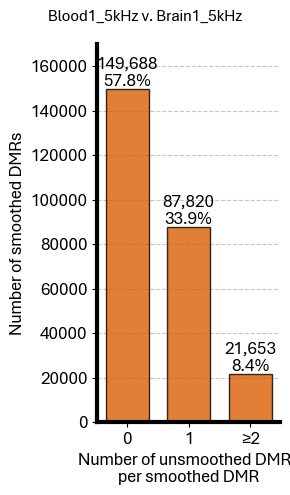

In [82]:
# initialize figure
fig, ax = plt.subplots(figsize=(3, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

bars = ax.bar(collapsed.index, 
              collapsed.values,
              width=0.7,
             color=color_dict['smoothed'],
              edgecolor='black',
              alpha=0.8,
             zorder=2)

for i, bar in enumerate(bars):
    count = collapsed.iloc[i]
    pct = collapsed_pct.iloc[i]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=tick_size
    )

ax.set_ylim(0, 170000)

ax.tick_params(axis='both', labelsize=tick_size)
ax.set_xlabel("Number of unsmoothed DMRs\nper smoothed DMR", fontsize=tick_size)
ax.set_ylabel("Number of smoothed DMRs", fontsize=tick_size)

plt.suptitle(title)

plt.tight_layout()
plt.show()

#### Calculate boundary shift

In [38]:
# collapse unsmoothed regions per smoothed DMR
unsmooth_span = (
    overlaps
    .groupby("smooth_id")
    .agg(
        u_start_min=("u_start", "min"),
        u_end_max=("u_end", "max"),
        s_start=("start", "first"),
        s_end=("end", "first")
    )
    .reset_index()
)

# boundary shifts
unsmooth_span["left_shift_bp"] = (
    unsmooth_span["s_start"] - unsmooth_span["u_start_min"]
)

unsmooth_span["right_shift_bp"] = (
    unsmooth_span["s_end"] - unsmooth_span["u_end_max"]
)

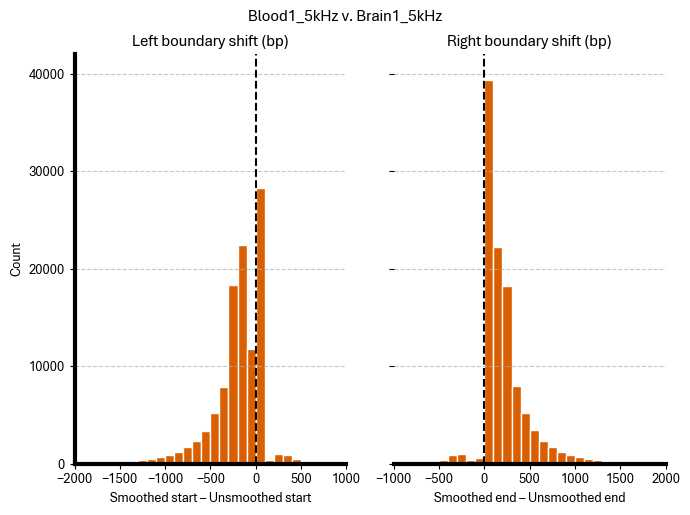

In [92]:
# Define shared bin edges (100 bp bins across your range)
bins = np.arange(-2000, 2000 + 100, 100)

fig, axes = plt.subplots(1, 2, figsize=(7, 5))

# Compute histograms first (so we can sync y-axis)
left_counts, _ = np.histogram(unsmooth_span["left_shift_bp"], bins=bins)
right_counts, _ = np.histogram(unsmooth_span["right_shift_bp"], bins=bins)

# Shared y max
ymax = 40000

# --- Left ---
axes[0].hist(
    unsmooth_span["left_shift_bp"],
    color=color_dict['smoothed'],
    bins=bins, edgecolor='white',
)
axes[0].axvline(0, linestyle="--", color="black")
axes[0].set_title("Left boundary shift (bp)")
axes[0].set_xlabel("Smoothed start – Unsmoothed start")
axes[0].set_ylabel("Count")
axes[0].set_xlim(-2000, 1000)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].spines['bottom'].set_linewidth(3)
axes[0].spines['left'].set_linewidth(3)

# --- Right ---
axes[1].hist(
    unsmooth_span["right_shift_bp"],
    color=color_dict['smoothed'],
    bins=bins, edgecolor='white',
)
axes[1].axvline(0, linestyle="--", color="black")
axes[1].set_title("Right boundary shift (bp)")
axes[1].set_xlabel("Smoothed end – Unsmoothed end")
#axes[1].set_ylabel("Count")
axes[1].set_xlim(-1000, 2000)
axes[1].spines[["top", "left", "right"]].set_visible(False)
axes[1].spines['bottom'].set_linewidth(3)
axes[1].set_yticklabels([])

# Shared axis settings
for ax in axes:
    ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)
    ax.set_ylim(0, ymax * 1.05)  # small padding
    ax.set_yticks(np.linspace(0, ymax, 5))  # same ticks



plt.tight_layout()
plt.suptitle(title, y=1.02)
plt.show()

In [65]:
smooth_counts[smooth_counts['n_unsmoothed_segments'] == 2].head(20)

,chrom,start,end,name,smooth_id,n_unsmoothed_segments
4,chr1,19683,20983,chr1:19683-20983,145170,2
10,chr1,50864,52474,chr1:50864-52474,145176,2
18,chr1,190206,192140,chr1:190206-192140,145184,2
29,chr1,380921,382869,chr1:380921-382869,145195,2
51,chr1,777359,778292,chr1:777359-778292,145217,2
52,chr1,779514,780998,chr1:779514-780998,145218,2
72,chr1,916382,918081,chr1:916382-918081,145238,2
76,chr1,927040,928168,chr1:927040-928168,145242,2
105,chr1,983958,984700,chr1:983958-984700,145271,2
127,chr1,1040684,1042026,chr1:1040684-1042026,145293,2
